# Milestone 2: Data Collection & Exploration

## Data Description

### Data Source
We downloaded data from the **DBAASP database** (Database of Antimicrobial Activity and Structure of Peptides), a database of experimentally measured antimicrobial peptide (AMP) activity. Each row represents one experimental measurement of a peptide's minimum inhibitory concentration (MIC) against a target microbial species. There are 80 unique sources, representing a unique paper or lab's data. 

### Format
The raw data contains **188,575 rows** and 13 columns: `Peptide ID`, `Peptide Sequence`, `Target Species`, `Activity Measure`, `Activity`, `Unit`, `pH`, `Ionic Strength mM`, `Salt Type`, `Medium`, `CFU`, `Note`, and `Reference`. There are 20,439 unique peptide sequences tested against 8,057 unique microbial strains.

### Preprocessing Steps

To make the data suitable for analysis, we applied the following preprocessing stepes:

| Step | Description | Rows remaining |
|------|-------------|----------------|
| Raw data | Initial data | 188,575 |
| Drop nulls | Removed rows with any missing values | 177,258 |
| Filter to MIC | Kept only `Activity Measure == MIC`; removed MBC, IC50, LC50, etc. | 135,441 |
| Drop duplicates | Removed exact duplicate rows | 128,203 |
| Handle range values | Rows with range activity (e.g. `16-32`) were removed | 117,360 |
| Handle thresholded values | Values like `>128` or `<1` were converted to their numeric boundary | — |
| Unit conversion | Converted `µg/mL` to `µM` using per-peptide MW (biopython); dropped modified/non-standard peptides where MW could not be computed | 96,502 |


**Range data** (e.g. `16-32 µg/mL`) for now was removed rather than imputed.There are some other strategies used by previous papers that take the midpoint, convert to log2 and take the midpoint, or take the end point. We may decide to instead employ these later (Padi). **Thresholded data** (e.g. `>128`) was converted to its boundary value (Padi). This is also a common strategy, and as there were more of these values (26,707), we decided that although it is a conservative approach, it was better than dropping the data. Alternative strategies we may explore are some type of survival analysis (Zhang).

**Unit standardization**: MIC values were reported in either `µM` or `µg/mL`. To unify the target variable, `µg/mL` values were converted to `µM` using molecular weight calculated from the peptide sequence via biopython. Rows where MW could not be computed (e.g. heavily modified or non-standard sequences) were dropped.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils import molecular_weight
from Bio.Seq import Seq

sns.set_theme(style='whitegrid')

# --- Load and clean ---
df = pd.read_csv('MIC_data_original.csv')

cleaned_df = df[['Peptide Sequence','Target Species','Activity Measure','Activity','Unit','Reference']].copy()
cleaned_df = cleaned_df.dropna()
cleaned_df = cleaned_df[cleaned_df['Activity Measure'] == 'MIC']
cleaned_df = cleaned_df.drop_duplicates()

def convert_thresholded(val):
    val = str(val).strip()
    if val.startswith('>') or val.startswith('<'):
        return pd.to_numeric(val[1:], errors='coerce')
    return pd.to_numeric(val, errors='coerce')

cleaned_df['Activity'] = cleaned_df['Activity'].apply(convert_thresholded)
cleaned_df = cleaned_df[cleaned_df['Activity'].notna()].copy()
cleaned_df['Activity'] = cleaned_df['Activity'].astype(float)

def peptide_mw(seq):
    try:
        return molecular_weight(Seq(seq), seq_type='protein')
    except Exception:
        return None

df_conv = cleaned_df.copy()
df_conv['MW'] = df_conv['Peptide Sequence'].apply(peptide_mw)
df_conv = df_conv[df_conv['MW'].notna() & (df_conv['MW'] > 0)]

df_conv['Activity_uM'] = df_conv.apply(
    lambda row: (row['Activity'] / row['MW']) * 1000
    if row['Unit'].strip() == 'µg/ml' else row['Activity'], axis=1
)

viz = df_conv.copy()
viz['log2_uM'] = np.log2(viz['Activity_uM'])
viz['length'] = viz['Peptide Sequence'].str.len()

print(f'Final dataset shape: {viz.shape}')
print(f'Unique peptides: {viz["Peptide Sequence"].nunique()}')
print(f'Unique species: {viz["Target Species"].nunique()}')
print(f'\nlog2(MIC µM) summary:')
print(viz['log2_uM'].describe().round(2))

Final dataset shape: (96504, 10)
Unique peptides: 13495
Unique species: 4856

log2(MIC µM) summary:
count    96504.00
mean         3.80
std          2.69
min        -16.08
25%          2.00
50%          3.91
75%          5.78
max         16.07
Name: log2_uM, dtype: float64


## Exploratory Analysis

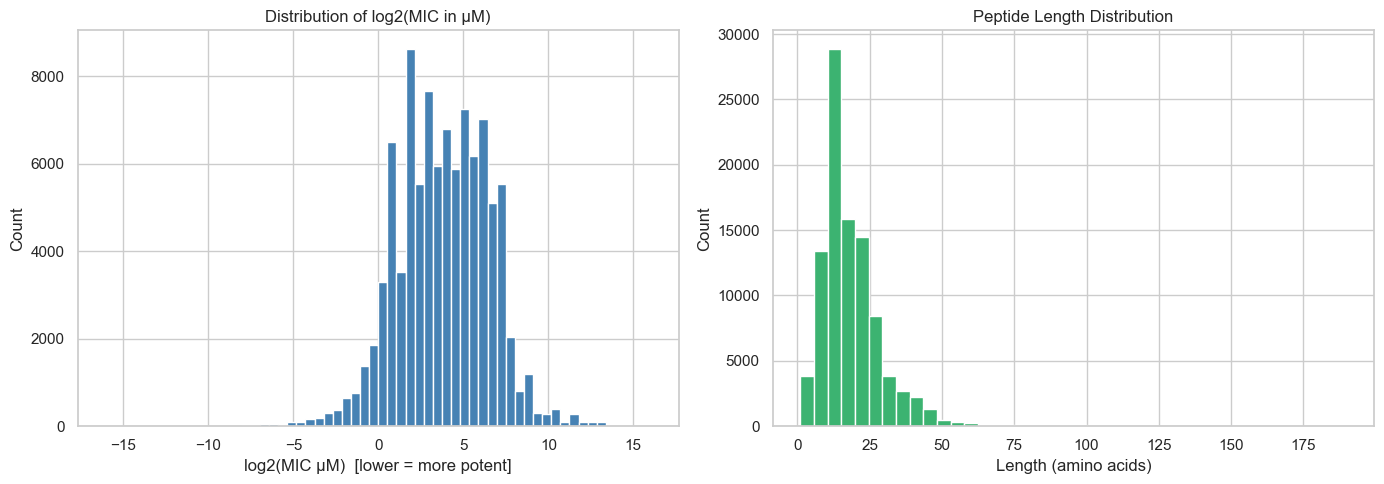

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MIC distribution
axes[0].hist(viz['log2_uM'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of log2(MIC in µM)')
axes[0].set_xlabel('log2(MIC µM)  [lower = more potent]')
axes[0].set_ylabel('Count')

# Peptide length distribution
axes[1].hist(viz['length'], bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Peptide Length Distribution')
axes[1].set_xlabel('Length (amino acids)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**MIC distribution**: log2(MIC) is roughly normal, centered around 3–5 (i.e. 8–32 µM), with a slight right skew toward high (weak) MIC values. This seems to be a reasonable range of potency against different strains. The spikes we see represent the thresholding present in the data, as labs often test potency at specific concentrations (2,4,8,etc)

**Peptide length**: Right-skewed with most peptides between 10–30 amino acids. There are some very short and very long amino acids, that we may choose to filter out later. 

TypeError: 'Axes' object is not subscriptable

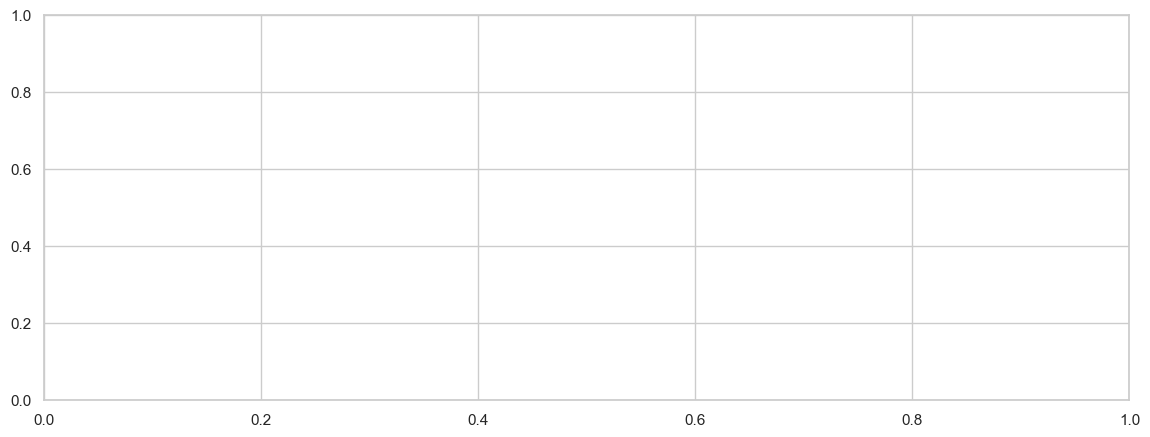

In [16]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Length vs activity
axes[1].scatter(viz['length'], viz['log2_uM'], alpha=0.03, s=5, color='slateblue')
axes[1].set_title('Peptide Length vs Activity')
axes[1].set_xlabel('Length (aa)')
axes[1].set_ylabel('log2(MIC µM)  [lower = more potent]')

plt.tight_layout()
plt.show()


**Length vs activity**: No strong linear trend, but longer peptides show a slight downward trend in median MIC (i.e. slightly more potent on average). All lengths have a high variance, suggesting other features besides length are important. 

Total unique peptide–species combos: 86448
Combos tested exactly once: 80122
Combos tested more than once: 6326
Total repeat measurements: 10056

Peptides tested only once: 1482
Peptides tested 10+ times: 3196

=== Tests per target species ===
Target Species
Escherichia coli ATCC 25922              6463
Staphylococcus aureus ATCC 25923         3973
Pseudomonas aeruginosa ATCC 27853        3544
Staphylococcus aureus ATCC 29213         2187
Staphylococcus aureus                    1731
Pseudomonas aeruginosa PAO1              1473
Escherichia coli                         1412
Acinetobacter baumannii ATCC 19606       1310
Enterococcus faecalis ATCC 29212         1190
Staphylococcus epidermidis ATCC 12228    1172
dtype: int64


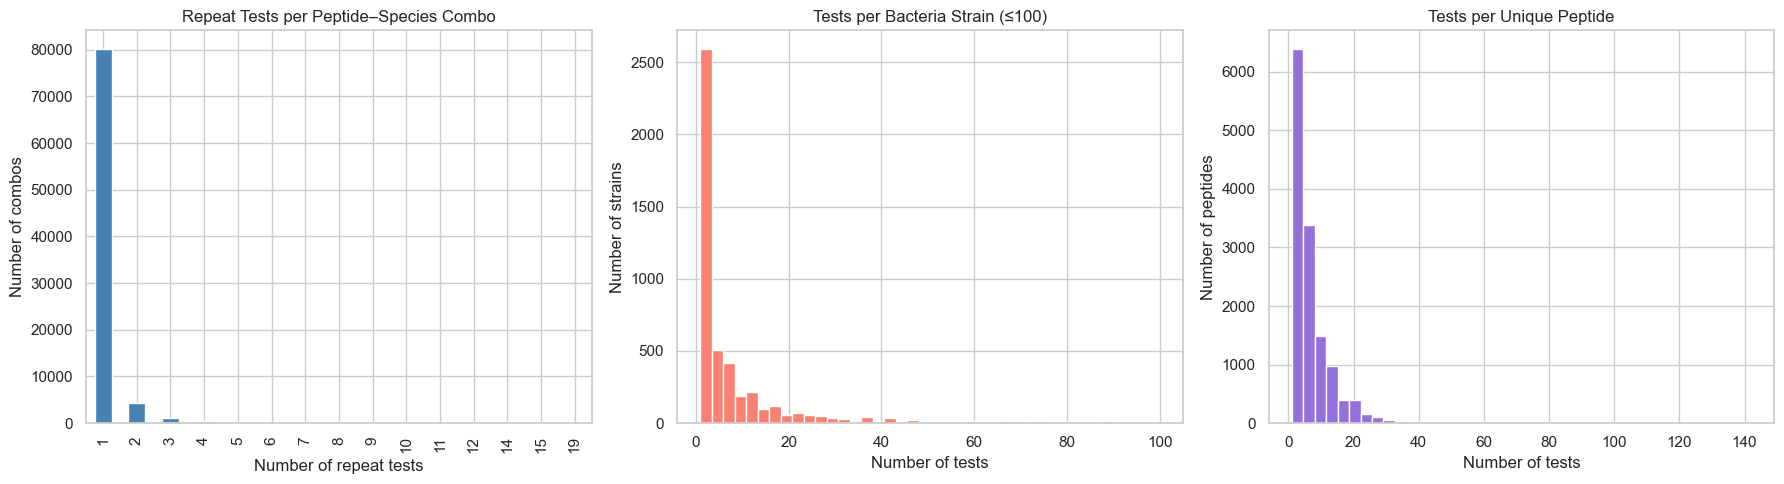

In [ ]:
combo_counts = viz.groupby(['Peptide Sequence', 'Target Species']).size()
strain_counts = viz.groupby('Target Species').size().sort_values(ascending=False)
peptide_counts = viz.groupby('Peptide Sequence').size().sort_values(ascending=False)

print(f'Total unique peptide–species combos: {len(combo_counts)}')
print(f'Combos tested exactly once: {(combo_counts == 1).sum()}')
print(f'Combos tested more than once: {(combo_counts > 1).sum()}')
print(f'Total repeat measurements: {(combo_counts - 1).sum()}')
print(f'\nPeptides tested only once: {(peptide_counts == 1).sum()}')
print(f'Peptides tested 10+ times: {(peptide_counts >= 10).sum()}')

# 2. Tests per bacteria (strain)
strain_counts = viz.groupby("Target Species").size().sort_values(ascending=False)
print("\n=== Tests per target species ===")
print(strain_counts.head(10))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

combo_counts.value_counts().sort_index().head(15).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Repeat Tests per Peptide–Species Combo')
axes[0].set_xlabel('Number of repeat tests')
axes[0].set_ylabel('Number of combos')

axes[1].hist(strain_counts[strain_counts <= 100].values, bins=40, color='salmon', edgecolor='white')
axes[1].set_title('Tests per Bacteria Strain (≤100)')
axes[1].set_xlabel('Number of tests')
axes[1].set_ylabel('Number of strains')

axes[2].hist(peptide_counts.values, bins=40, color='mediumpurple', edgecolor='white')
axes[2].set_title('Tests per Unique Peptide')
axes[2].set_xlabel('Number of tests')
axes[2].set_ylabel('Number of peptides')

plt.tight_layout()
plt.show()

**Repeat measurements**: The vast majority of peptide–species combinations (93%) were tested exactly once. Only 6,326 combos have repeat measurements, contributing ~10,000 extra rows. 

**Species coverage**: A small number of standard lab strains (e.g. *E. coli* ATCC 25922, *S. aureus* ATCC 25923) dominate the dataset, while most of the 8,000+ strains have very few measurements. It is also worth noting that there are variations of the e coli strains, including some measurements where the lab did not specify what strain of the bacteria they used. 

**Peptide coverage**: Peptide test counts follow a heavy-tailed distribution — a minority of well-studied peptides account for a disproportionate share of measurements. When splitting test and train, we want to account for this to ensure our model generalizes well to new, unseen peptides. 


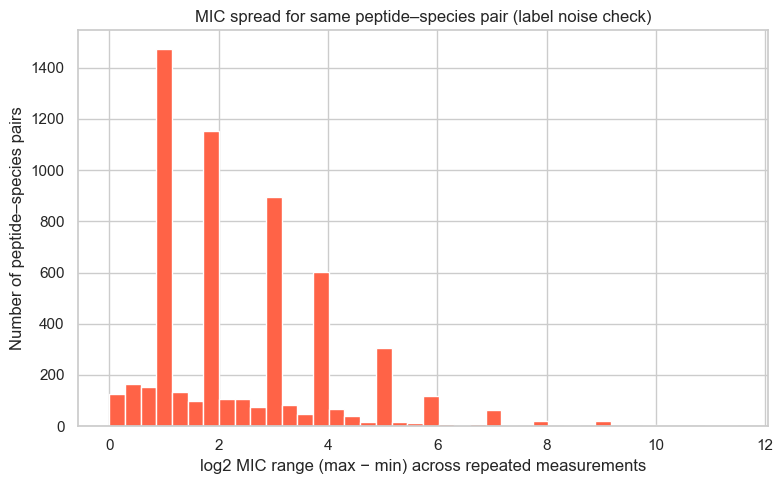

  2751 peptide–species pairs have >4-fold MIC disagreement (3.2% of pairs)


In [ ]:

# ── 7. Label noise: MIC spread for same peptide–species pair ─────────────────
spread = (viz.groupby(["Peptide Sequence", "Target Species"])["log2_uM"]
            .agg(lambda x: x.max() - x.min())
            .reset_index(name="log2_spread"))
spread_nonzero = spread[spread["log2_spread"] > 0]
plt.figure(figsize=(8, 5))
plt.hist(spread_nonzero["log2_spread"], bins=40, color="tomato", edgecolor="white")
plt.title("MIC spread for same peptide–species pair (label noise check)")
plt.xlabel("log2 MIC range (max − min) across repeated measurements")
plt.ylabel("Number of peptide–species pairs")
plt.tight_layout()
plt.show()
noisy = (spread["log2_spread"] > 2).sum()
print(f"  {noisy} peptide–species pairs have >4-fold MIC disagreement ({100*noisy/len(spread):.1f}% of pairs)")

### What Remains Unexplained
- Some (while not too many) MIC variation may reflect lab-to-lab differences in assay conditions (pH, ionic strength, inoculum size) rather than true potency differences.
- Thresholded MIC values (`>128`) introduce right-censoring; although we used the exact value, this overestimates how potent they are. 

## References

Padi, S., Mondal, K., Hoogerheide, D.P. et al. AI-driven antimicrobial peptide characterization unveils novel motifs for drug design. *Sci Rep* 16, 829 (2026). https://doi.org/10.1038/s41598-025-30419-1

Zhang M, Wang C, O'Connor A. A hierarchical Bayesian latent class mixture model with censorship for detection of linear temporal changes in antibiotic resistance. *PLoS One*. 2020 Jan 31;15(1):e0220427. doi: 10.1371/journal.pone.0220427. PMID: 32004341; PMCID: PMC6993983.
